In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')   


path_orders = "../data/olist_orders_dataset.csv"
path_items = "../data/olist_order_items_dataset.csv"
path_products = "../data/olist_products_dataset.csv"
path_reviews = "../data/olist_order_reviews_dataset.csv"
path_cat_trans = "../data/product_category_name_translation.csv"


orders = pd.read_csv(path_orders)
items = pd.read_csv(path_items)
products = pd.read_csv(path_products)
reviews = pd.read_csv(path_reviews)
cat_trans = pd.read_csv(path_cat_trans)


for cədvəl in [orders, items, products, reviews, cat_trans]:
    cədvəl.columns = cədvəl.columns.str.strip()


df = orders.merge(items, on="order_id", how="inner")
df = df.merge(products, on="product_id", how="left")
df = df.merge(cat_trans, on="product_category_name", how="left")
df = df.merge(
    reviews[["order_id", "review_score"]], on="order_id", how="left"
)



In [9]:
print(f"Merge edilmiş ümumi sətir sayı: {len(df):,}")
print(f"Ümumi unikal order_id sayı: {df['order_id'].nunique():,}")
print(f"Ümumi unikal customer_id sayı: {df['customer_id'].nunique():,}" if 'customer_id' in df.columns else "")
print(f"Ümumi unikal product_id sayı: {df['product_id'].nunique():,}" if 'product_id' in df.columns else "")


delivered = df[df['order_status'] == 'delivered'].copy()
print(f"\nDelivered item-sətri: {len(delivered):,}")
print(f"Delivered unikal sifariş: {delivered['order_id'].nunique():,}")


print("\nOrder Status Sayları:")
print(df['order_status'].value_counts())


print(f"\nTəkrarlanan  sətir sayı: {df.duplicated().sum():,}")


print("\nBoş Dəyərlər (Null Sayı və Faizi):")
null_data = pd.DataFrame({
    'Null Sayı': df.isnull().sum(),
    'Faiz (%)': (df.isnull().sum() / len(df)) * 100
})
print(null_data[null_data['Null Sayı'] > 0])

Merge edilmiş ümumi sətir sayı: 113,314
Ümumi unikal order_id sayı: 98,666
Ümumi unikal customer_id sayı: 98,666
Ümumi unikal product_id sayı: 32,951

Delivered item-sətri: 110,840
Delivered unikal sifariş: 96,478

Order Status Sayları:
order_status
delivered      110840
shipped          1196
canceled          546
invoiced          364
processing        358
unavailable         7
approved            3
Name: count, dtype: int64

Təkrarlanan  sətir sayı: 399

Boş Dəyərlər (Null Sayı və Faizi):
                               Null Sayı  Faiz (%)
order_approved_at                     15      0.01
order_delivered_carrier_date        1203      1.06
order_delivered_customer_date       2475      2.18
product_category_name               1612      1.42
product_name_lenght                 1612      1.42
product_description_lenght          1612      1.42
product_photos_qty                  1612      1.42
product_weight_g                      18      0.02
product_length_cm                     18     

In [10]:
for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    delivered[col] = pd.to_datetime(delivered[col])

delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

total_revenue = delivered['price'].sum()
order_revenue = delivered.groupby('order_id')['price'].sum()
aov = order_revenue.mean()
avg_delivery = delivered['delivery_days'].mean()
avg_review = delivered['review_score'].mean()
print(f"KPI 1 — Ümumi gəlir: {total_revenue:,.2f} BRL")
print(f"KPI 2 — Ortalama sifariş dəyəri (AOV): {aov:.2f} BRL")
print(f"KPI 3 — Ortalama çatdırılma müddəti: {avg_delivery:.2f} gün")
print(f"KPI 4 — Ortalama review score: {avg_review:.2f} / 5")

KPI 1 — Ümumi gəlir: 13,279,836.59 BRL
KPI 2 — Ortalama sifariş dəyəri (AOV): 137.65 BRL
KPI 3 — Ortalama çatdırılma müddəti: 12.01 gün
KPI 4 — Ortalama review score: 4.08 / 5


In [11]:
category_kpi = delivered.groupby('product_category_name_english').agg(
    Revenue=('price', 'sum'),
    Orders=('order_id', 'nunique'),
    Avg_Review=('review_score', 'mean'),
    Avg_Delivery=('delivery_days', 'mean')
).reset_index()
print(f"Unikal kateqoriya sayı: {category_kpi.shape[0]}")
category_kpi.sort_values('Revenue', ascending=False).head(10)

Unikal kateqoriya sayı: 71


,product_category_name_english,Revenue,Orders,Avg_Review,Avg_Delivery
43,health_beauty,"1,237,439.95",8647,4.19,11.52
70,watches_gifts,"1,167,246.63",5495,4.07,12.19
7,bed_bath_table,"1,037,177.69",9272,3.92,12.34
65,sports_leisure,"960,189.09",7530,4.17,11.69
15,computers_accessories,"896,243.28",6530,3.98,12.80
39,furniture_decor,"718,344.78",6307,3.95,12.40
49,housewares,"617,836.73",5743,4.11,10.46
20,cool_stuff,"612,071.86",3559,4.19,11.91
5,auto,"580,263.44",3810,4.12,11.77
69,toys,"472,109.78",3804,4.21,11.24


In [12]:
top5_revenue = category_kpi.sort_values('Revenue', ascending=False).head(5)
bottom5_revenue = category_kpi.sort_values('Revenue', ascending=True).head(5)
print("Top 5 :")
print(top5_revenue[['product_category_name_english', 'Revenue', 'Orders']].to_string(index=False))
print()
print("Bottom 5 :")
print(bottom5_revenue[['product_category_name_english', 'Revenue', 'Orders']].to_string(index=False))


Top 5 :
product_category_name_english      Revenue  Orders
                health_beauty 1,237,439.95    8647
                watches_gifts 1,167,246.63    5495
               bed_bath_table 1,037,177.69    9272
               sports_leisure   960,189.09    7530
        computers_accessories   896,243.28    6530

Bottom 5 :
product_category_name_english  Revenue  Orders
        security_and_services   283.29       2
    fashion_childrens_clothes   519.95       7
            cds_dvds_musicals   730.00      12
               home_comfort_2   760.27      24
                      flowers 1,110.04      29


In [13]:
category_kpi_reliable = category_kpi[category_kpi['Orders'] >= 20]
top5_review = category_kpi_reliable.sort_values('Avg_Review', ascending=False).head(5)
bottom5_review = category_kpi_reliable.sort_values('Avg_Review', ascending=True).head(5)

print("Top 5 (review score, n>=20):")
print(top5_review[['product_category_name_english', 'Avg_Review', 'Orders']].to_string(index=False))
print()
print("Bottom 5 (review score, n>=20):")
print(bottom5_review[['product_category_name_english', 'Avg_Review', 'Orders']].to_string(index=False))

print()


for c in ['security_and_services', 'fashion_childrens_clothes']:
    row = category_kpi[category_kpi['product_category_name_english'] == c]
    print(row[['product_category_name_english', 'Avg_Review', 'Orders']].to_string(index=False))


Top 5 (review score, n>=20):
        product_category_name_english  Avg_Review  Orders
               books_general_interest        4.51     496
                       books_imported        4.51      50
              costruction_tools_tools        4.44      97
small_appliances_home_oven_and_coffee        4.44      72
                              flowers        4.42      29

Bottom 5 (review score, n>=20):
product_category_name_english  Avg_Review  Orders
          diapers_and_hygiene        3.38      25
             office_furniture        3.52    1254
               home_comfort_2        3.63      24
        fashion_male_clothing        3.76     106
              fixed_telephony        3.76     212

product_category_name_english  Avg_Review  Orders
        security_and_services        2.50       2
product_category_name_english  Avg_Review  Orders
    fashion_childrens_clothes        5.00       7


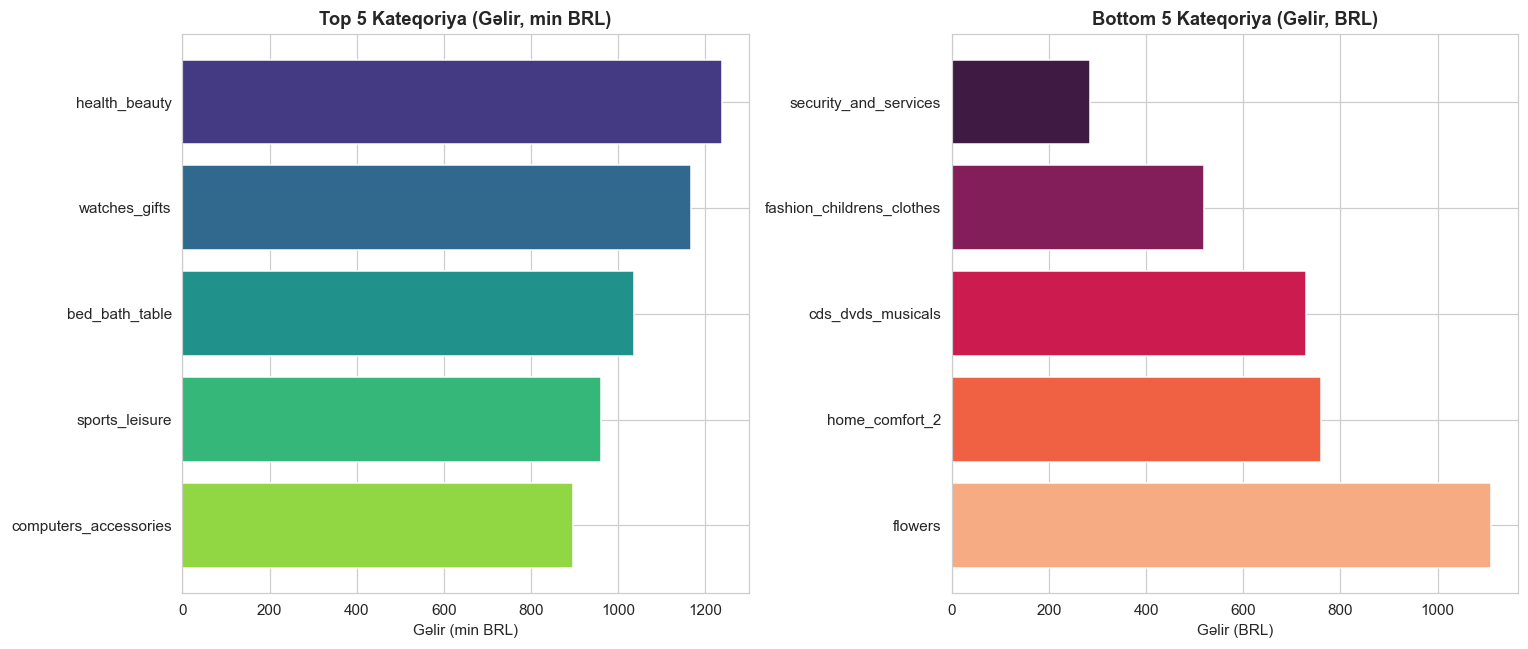

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top5_revenue['product_category_name_english'][::-1],
             top5_revenue['Revenue'][::-1] / 1000, color=sns.color_palette('viridis', 5)[::-1])
axes[0].set_title('Top 5 Kateqoriya (Gəlir, min BRL)', fontweight='bold')
axes[0].set_xlabel('Gəlir (min BRL)')

axes[1].barh(bottom5_revenue['product_category_name_english'][::-1],
             bottom5_revenue['Revenue'][::-1], color=sns.color_palette('rocket', 5)[::-1])
axes[1].set_title('Bottom 5 Kateqoriya (Gəlir, BRL)', fontweight='bold')
axes[1].set_xlabel('Gəlir (BRL)')
plt.tight_layout()
plt.savefig('top_bottom5_categories.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
corr = category_kpi_reliable['Avg_Delivery'].corr(category_kpi_reliable['Avg_Review'])
print(f"Korrelyasiya (Avg_Delivery vs Avg_Review, kateqoriya səviyyəsində): r = {corr:.3f}")


Korrelyasiya (Avg_Delivery vs Avg_Review, kateqoriya səviyyəsində): r = -0.416


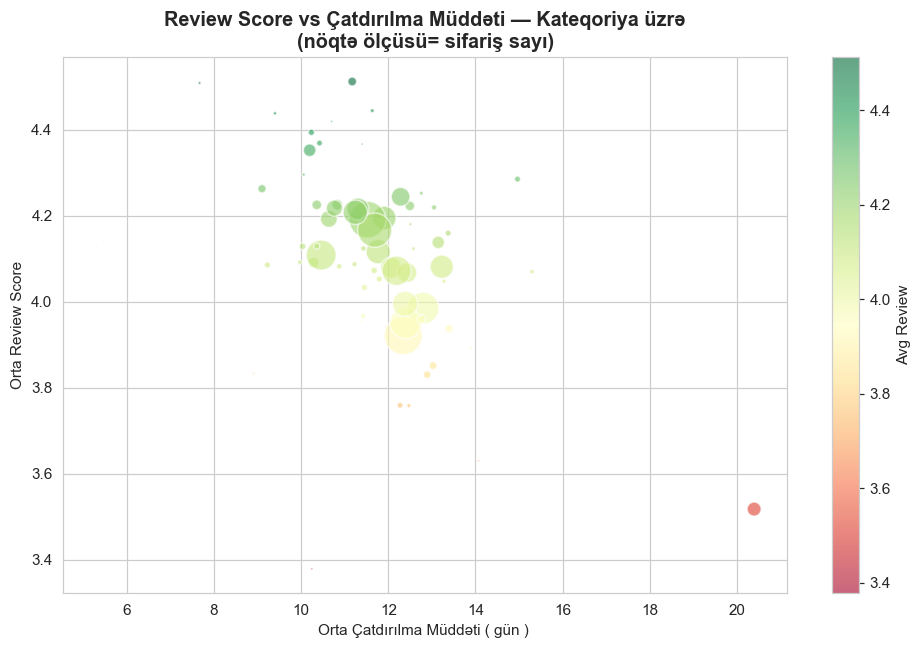

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(category_kpi_reliable['Avg_Delivery'], category_kpi_reliable['Avg_Review'],
                      s=category_kpi_reliable['Orders'] / 15, alpha=0.6,
                      c=category_kpi_reliable['Avg_Review'], cmap='RdYlGn', edgecolor='white')
ax.set_title('Review Score vs Çatdırılma Müddəti — Kateqoriya üzrə\n(nöqtə ölçüsü= sifariş sayı)',
              fontsize=13, fontweight='bold')
ax.set_xlabel('Orta Çatdırılma Müddəti ( gün ) ')
ax.set_ylabel('Orta Review Score')
plt.colorbar(scatter, label='Avg Review')
plt.tight_layout()
plt.savefig('review_vs_delivery_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
avg_delivery_overall = category_kpi_reliable['Avg_Delivery'].mean()
avg_review_overall = category_kpi_reliable['Avg_Review'].mean()
flagged = category_kpi_reliable[
    (category_kpi_reliable['Avg_Delivery'] > avg_delivery_overall) &
    (category_kpi_reliable['Avg_Review'] < avg_review_overall)
].sort_values('Avg_Delivery', ascending=False)
print(f"Kateqoriya-səviyyəli orta çatdırılma: {avg_delivery_overall:.2f} gün, orta review: {avg_review_overall:.2f}")
print(f"Flag edilmiş kateqoriya sayı: {len(flagged)} / {len(category_kpi_reliable)}")
print()
flagged[['product_category_name_english', 'Avg_Delivery', 'Avg_Review', 'Orders']].head(10)


Kateqoriya-səviyyəli orta çatdırılma: 11.67 gün, orta review: 4.11
Flag edilmiş kateqoriya sayı: 21 / 67



,product_category_name_english,Avg_Delivery,Avg_Review,Orders
57,office_furniture,20.40,3.52,1254
12,christmas_supplies,15.30,4.07,125
46,home_comfort_2,14.07,3.63,24
41,furniture_mattress_and_upholstery,13.89,3.89,37
40,furniture_living_room,13.39,3.94,414
33,fashion_underwear_beach,13.28,4.05,117
42,garden_tools,13.23,4.08,3448
47,home_confort,13.03,3.85,392
4,audio,12.89,3.83,348
15,computers_accessories,12.80,3.98,6530


In [18]:
seller_kpi = delivered.groupby('seller_id').agg(
    Revenue=('price', 'sum'),
    Orders=('order_id', 'nunique'),
    Avg_Review=('review_score', 'mean')
).reset_index()
print(f"Ümumi satıcı sayı: {seller_kpi.shape[0]:,}")
total_seller_revenue = seller_kpi['Revenue'].sum()
top10_sellers = seller_kpi.sort_values('Revenue', ascending=False).head(10)
top10_pct = top10_sellers['Revenue'].sum() / total_seller_revenue * 100
print(f"Top 10 satıcının ümumi gəlirdəki payı: {top10_pct:.2f}%")
print()
print("Top 10 satıcı:")
top10_sellers[['seller_id', 'Revenue', 'Orders', 'Avg_Review']]


Ümumi satıcı sayı: 2,970
Top 10 satıcının ümumi gəlirdəki payı: 13.28%

Top 10 satıcı:


,seller_id,Revenue,Orders,Avg_Review
834,4869f7a5dfa277a7dca6462dcf3b52b2,"226,987.93",1124,4.14
982,53243585a1d6dc2643021fd1853d8905,"217,940.44",348,4.13
858,4a3ca9315b744ce9f8e9374361493884,"199,408.32",1772,3.83
2903,fa1c13f2614d7b5c4749cbc52fecda94,"190,917.14",578,4.37
1480,7c67e1448b00f6e969d365cea6b010ab,"188,063.83",973,3.35
1504,7e93a43ef30c4f03f38b393420bc753a,"165,981.49",319,4.36
2543,da8622b14eb17ae2831f4ac5b9dab84a,"162,303.67",1311,4.08
1450,7a67c85e85bb2ce8582c35f2203ad736,"140,238.65",1145,4.27
188,1025f0e2d44d7041d6cf58b6550e0bfa,"139,720.16",910,3.87
1758,955fee9216a65b617aa5c0531780ce60,"131,906.71",1261,4.09


In [20]:
bottom5_sellers = seller_kpi.sort_values('Revenue', ascending=True).head(5)
print("Bottom 5 satıcı:")
bottom5_sellers


Bottom 5 satıcı:


,seller_id,Revenue,Orders,Avg_Review
1414,77128dec4bec4878c37ab7d6169d6f26,6.50,1,5.00
363,1fa2d3def6adfa70e58c276bb64fe5bb,6.90,1,1.00
1319,702835e4b785b67a084280efca355756,7.60,1,5.00
2007,ad14615bdd492b01b0d97922e87cb87f,8.25,1,5.00
846,4965a7002cca77301c82d3f91b82e1a9,8.49,1,5.00


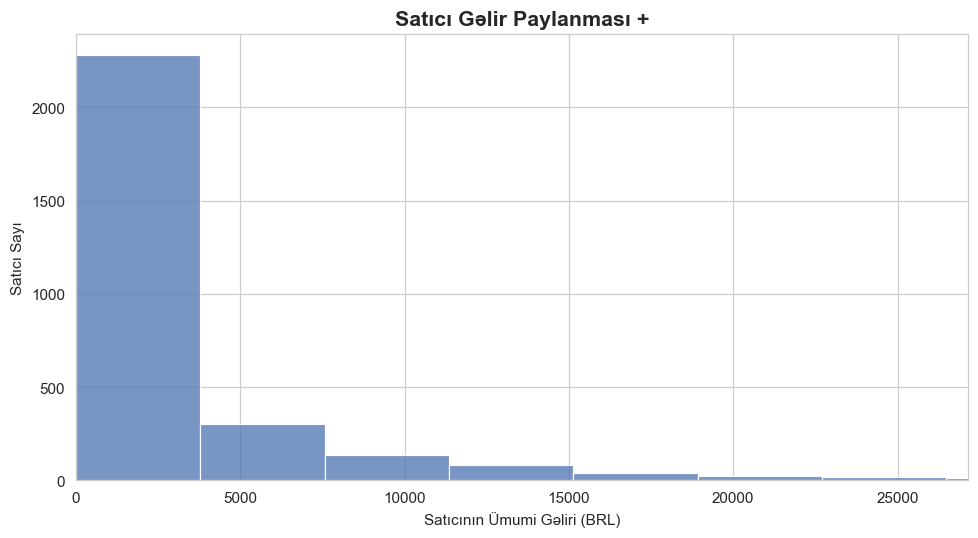

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(seller_kpi['Revenue'], bins=60, color='#4C72B0', edgecolor='white', ax=ax)
ax.set_title('Satıcı Gəlir Paylanması +', fontsize=14, fontweight='bold')
ax.set_xlabel('Satıcının Ümumi Gəliri (BRL)')
ax.set_ylabel('Satıcı Sayı')
ax.set_xlim(0, seller_kpi['Revenue'].quantile(0.97))
plt.tight_layout()
plt.savefig('seller_revenue_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
delivered['YearMonth'] = delivered['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_kpi = delivered.groupby('YearMonth').agg(
    Revenue=('price', 'sum'),
    Orders=('order_id', 'nunique'),
    Avg_Review=('review_score', 'mean'),
    Avg_Delivery=('delivery_days', 'mean')
).reset_index()
monthly_kpi['AOV'] = monthly_kpi['Revenue'] / monthly_kpi['Orders']
monthly_kpi.round(2)


,YearMonth,Revenue,Orders,Avg_Review,Avg_Delivery,AOV
0,2016-09,134.97,1,1.00,54.00,134.97
1,2016-10,"40,451.80",265,3.91,19.09,152.65
2,2016-12,10.90,1,5.00,4.00,10.90
3,2017-01,"112,573.39",750,4.17,12.07,150.10
4,2017-02,"235,483.40",1653,4.18,12.59,142.46
5,2017-03,"360,865.25",2546,4.13,12.41,141.74
6,2017-04,"341,209.62",2303,4.10,14.27,148.16
7,2017-05,"492,620.44",3546,4.20,10.90,138.92
8,2017-06,"425,387.66",3135,4.19,11.46,135.69
9,2017-07,"484,637.74",3872,4.18,10.98,125.16


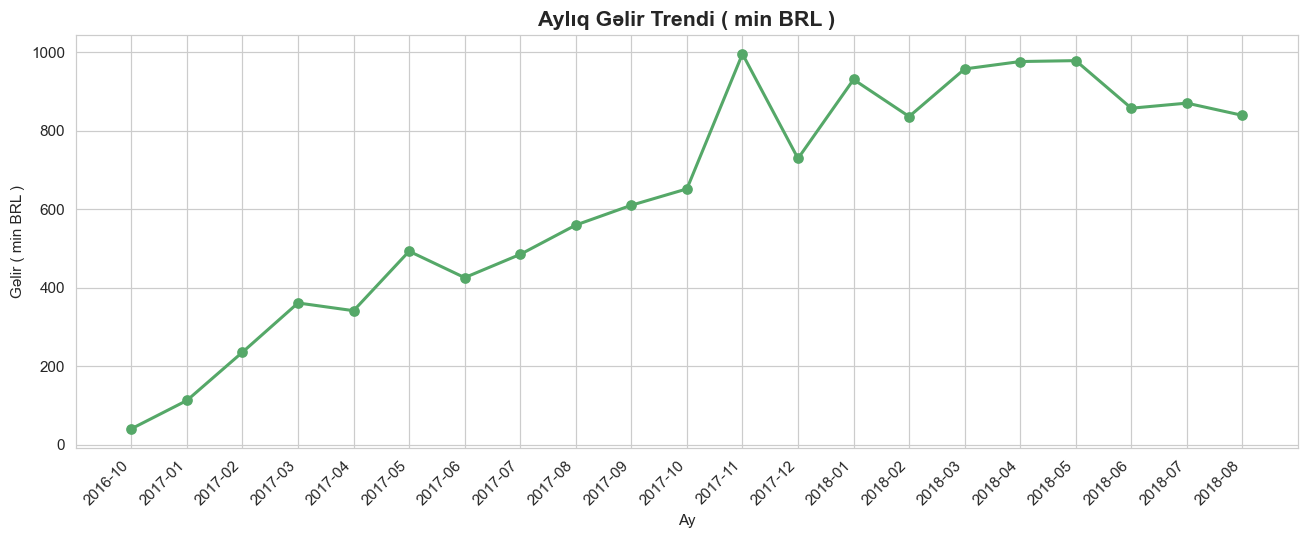

In [23]:
monthly_plot = monthly_kpi[monthly_kpi['Orders'] >= 10].copy()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_plot['YearMonth'], monthly_plot['Revenue'] / 1000, marker='o',
        color='#55A868', linewidth=2)
ax.set_title('Aylıq Gəlir Trendi ( min BRL )', fontsize=14, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('Gəlir ( min BRL )')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
